In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
import matplotlib as mpl
from tqdm import tqdm
from scipy.stats.mstats import ttest_onesamp
from scipy.optimize import curve_fit


#mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use(['science','notebook'])


CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=CB_color_cycle)

plt.rcParams['font.size'] = 18
plt.rcParams['legend.fontsize'] = 14

In [16]:
### DATA argregation

nametemplate = "IDS/dipoles_1stshell_t0_id"
res = np.zeros((100,3))
res[:,0] = np.arange(1,101)
for i in range(1,101):
    data = np.loadtxt(f"{nametemplate}_E{i}.txt")
    res[i-1,1] = np.mean(data[:,0])
    res[i-1,2] = np.std(data[:,0])/np.sqrt(50) * 3
    
np.savetxt(f"{nametemplate}_All.txt", res)

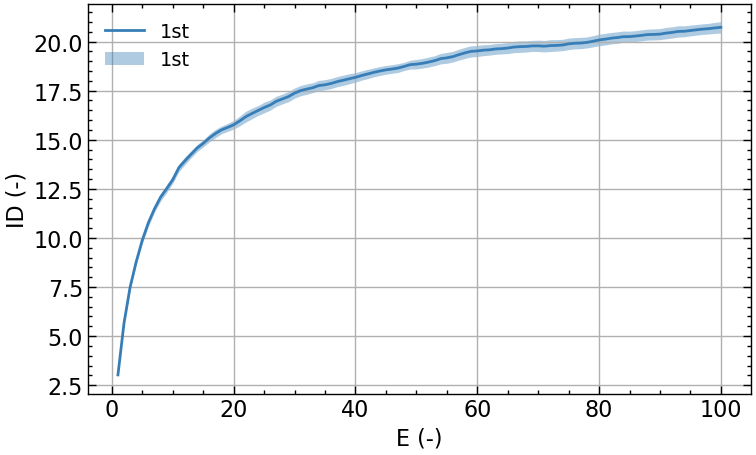

In [17]:
fig, ax = plt.subplots()

ax.set_xlabel("E (-)")
ax.set_ylabel("ID (-)")

ax.plot(res[:,0], res[:,1], label = "1st", ls = "-" , color = CB_color_cycle[0])
ax.fill_between(res[:,0], res[:,1]-res[:,2], res[:,1]+res[:,2], label = "1st", color = CB_color_cycle[0], alpha=0.4, lw=0)

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("autocorr_HDL.pdf")
plt.show()


fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation of the different dipoles: HDL")
ax.set_ylim((-0.5,1.1))
ax.set_xlim((0,1e3))


Name = "ref"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
print(Data)
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


Name = "1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "2nd"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "outref"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out2nd"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000 
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("autocorr_HDL.pdf")
plt.show()


def exp_model(x,a):
    return np.exp(-(x-0.001)/a)

Name = "ref"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000000 # micros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_ref = popt[0]
sig_ref = np.sqrt(pcov[0][0])
genData_ref = exp_model(Data[:,0],a_ref)

Name = "1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000000 # micros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_1st = popt[0]
sig_1st = np.sqrt(pcov[0][0])
genData_1st = exp_model(Data[:,0],a_1st)

Name = "2nd"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000000 # micros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_2nd = popt[0]
sig_2nd = np.sqrt(pcov[0][0])

genData_2nd = exp_model(Data[:,0],a_2nd)

Name = "out1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000000 # micros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_out1st = popt[0]
sig_out1st = np.sqrt(pcov[0][0])

genData_out1st = exp_model(Data[:,0],a_out1st)

Name = "out2nd"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000000 # micros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_out2nd = popt[0]
sig_out2nd = np.sqrt(pcov[0][0])

genData_out2nd = exp_model(Data[:,0],a_out2nd)

fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation Exponantial fits: HDL")
ax.set_xlim((0,1e3))
ax.set_ylim((-0.1,1.1))


Name = "ref"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns")


Name = "1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns")

# Name = "2nd"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd*1000:.2f}$\\pm${sig_2nd*1000:.2f}ns")

Name = "out1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_out1st, label = f"f-{Name} $\\tau$={a_out1st*1000:.2f}$\\pm${sig_out1st*1000:.2f}ns")

# Name = "out2nd"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out2nd, label = f"f-{Name} $\\tau$={a_out2nd*1000:.2f}$\\pm${sig_out2nd*1000:.2f}ns")

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("fit_autocorr_HDL.pdf")
plt.show()


fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation Exponantial fits: HDL")
ax.set_xlim((0,1e3))
ax.set_ylim((-0.1,1.1))

Name = "ref"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "2nd"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "out2nd"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


Name = "ref"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns", linestyle = '--')


Name = "1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns", linestyle = '--')

Name = "2nd"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=Data[0,1]
Data[:,2]/=Data[0,1]
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd*1000:.2f}$\\pm${sig_2nd*1000:.2f}ns", linestyle = '--')

Name = "out1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], genData_out1st, label = f"f-{Name} $\\tau$={a_out1st*1000:.2f}$\\pm${sig_out2nd*1000:.2f}ns", linestyle = '--')

# Name = "out2nd"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out2nd, label = f"f-{Name} $\\tau$={a_out2nd*1000:.2f}$\\pm${sig_out2nd*1000:.2f}ns", linestyle = '--')

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("fitnraw_autocorr_HDL.pdf")

plt.show()


fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation of the different dipoles: HDL")
ax.set_ylim((0.5,1.05))
ax.set_xlim((0,10))


Name = "ref"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


Name = "1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "2nd"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "out2nd"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
#plt.savefig("autocorr_HDL.pdf")
plt.show()

fig, ax = plt.subplots()

#ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation: HDL")
ax.set_xlim((-0.1,50))
ax.set_ylim((-0.1,1.1))

Name = "ref"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
#prevplot = ax.plot(Data[:,0], Data[:,1], label = f"ref $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns")
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
#prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns", ls="-.-")
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name, linestyle = "-.")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "2nd"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
#prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_2nd*1000:.2f}$\\pm${sig_2nd*1000:.2f}ns", ls)
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name, linestyle = ":")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

#Name = "out1st"
#Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
#Rescale = Data[0,1]
#Data[:,1]/= Rescale
#Data[:,2]/= Rescale
#Data[:,0]/=1000000
#prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_out1st*1000:.2f}$\\pm${sig_out1st*1000:.2f}ns")
#ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out2nd"

Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name, linestyle =  "--")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


# Name = "ref"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns", linestyle = '--')


# Name = "1st"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns", linestyle = '--')

# # Name = "2nd"
# # Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# # Data[:,1]/=Data[0,1]
# # Data[:,2]/=Data[0,1]
# # Data[:,0]/=1000000
# # prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd*1000:.2f}$\\pm${sig_2nd*1000:.2f}ns", linestyle = '--')

# Name = "out1st"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out1st, label = f"f-{Name} $\\tau$={a_out1st*1000:.2f}$\\pm${sig_out2nd*1000:.2f}ns", linestyle = '--')

# # Name = "out2nd"
# # Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# # Data[:,1]/=Data[0,1]
# # Data[:,2]/=Data[0,1]
# # Data[:,0]/=1000000
# # prevplot = ax.plot(Data[:,0], genData_out2nd, label = f"f-{Name} $\\tau$={a_out2nd*1000:.2f}$\\pm${sig_out2nd*1000:.2f}ns", linestyle = '--')

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("rawntime_autocorr_HDL.pdf", dpi=300)

plt.savefig("rawntime_autocorr_HDL.png", dpi=300)

plt.show()

fig, ax = plt.subplots()

#ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Crosscor (-)")
ax.set_title("Crosscorrelation of the different dipoles: HDL")
ax.set_xlim((0,50))
ax.set_ylim((-0.1,1.1))

Name = "ref_1st"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name, linestyle = '-')
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

#Name = "1st_out1st"
#Subnames=Name.split('_')
#Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
#Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
#Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
#Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
#Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
#Data[:,0]/=1000000
#prevplot = ax.plot(Data[:,0], Data[:,1], label = Name, linestyle = '-')
#ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "1st_2nd"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name, linestyle = '-.')
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "ref_2nd"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name, linestyle = ':')
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "2nd_out2nd"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name, linestyle = '--')
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("crosscorr_HDL.pdf")
plt.savefig("crosscorr_HDL.png")
plt.show()
plt.close()


# fig, ax = plt.subplots()

# #ax.set_xscale('log')
# ax.set_xlabel("Time (ns)")
# ax.set_ylabel("Crosscor (-)")
# ax.set_title("Crosscorrelation of the different dipoles: HDL")
# ax.set_xlim((-0.1,50.1))
# ax.set_ylim((-0.1,0.25))

# Name = "ref_outref"
# Subnames=Name.split('_')
# Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
# Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
# Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
# Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "1st_out1st"
# Subnames=Name.split('_')
# Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
# Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
# Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
# Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "2nd_out2nd"
# Subnames=Name.split('_')
# Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
# Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
# Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
# Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


# ax.legend()
# ax.grid()
# fig.set_size_inches((8,5))
# plt.tight_layout()
# plt.savefig("crosscorr_HDL.pdf")
# plt.show()


fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation Diff with Ref: HDL")
ax.set_xlim((0,1e3))
# ax.set_ylim((-1,1))


Name = "ref"
Ref = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
Rescale = Ref[0,1]
Ref[:,1]/=Rescale
Ref[:,2]/=Rescale
Ref[:,0]/=1000000

Name = "ref"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000

Data[:,1] -= Ref[:,1]
Data[:,2] += Ref[:,2]
Data_absmax = np.max(np.abs(Data[:,1]))
# Data[:,1] /= Data_absmax
# Data[:,2] /= Data_absmax

prevplot = ax.plot(Data[:,0], Data[:,1], label = f"ref $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000

Data[:,1] -= Ref[:,1]
Data[:,2] += Ref[:,2]
Data_absmax = np.max(np.abs(Data[:100,1]))
Data[:,1] /= Data_absmax
Data[:,2] /= Data_absmax

prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "2nd"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

Name = "out1st"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000000

Data[:,1] -= Ref[:,1]
Data[:,2] += Ref[:,2]
#Data_absmax = np.max(np.abs(Data[:,1]))
Data[:,1] /= Data_absmax
Data[:,2] /= Data_absmax

prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_out1st*1000:.2f}$\\pm${sig_out1st*1000:.2f}ns")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)

# Name = "out2nd"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:10**3,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.2, lw=0)


# Name = "ref
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref*1000:.2f}$\\pm${sig_ref*1000:.2f}ns", linestyle = '--')


# Name = "1st"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st*1000:.2f}$\\pm${sig_1st*1000:.2f}ns", linestyle = '--')

# # Name = "2nd"
# # Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# # Data[:,1]/=Data[0,1]
# # Data[:,2]/=Data[0,1]
# # Data[:,0]/=1000000
# # prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd*1000:.2f}$\\pm${sig_2nd*1000:.2f}ns", linestyle = '--')

# Name = "out1st"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Data[:,1]/=Data[0,1]
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out1st, label = f"f-{Name} $\\tau$={a_out1st*1000:.2f}$\\pm${sig_out2nd*1000:.2f}ns", linestyle = '--')

# # Name = "out2nd"
# # Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# # Data[:,1]/=Data[0,1]
# # Data[:,2]/=Data[0,1]
# # Data[:,0]/=1000000
# # prevplot = ax.plot(Data[:,0], genData_out2nd, label = f"f-{Name} $\\tau$={a_out2nd*1000:.2f}$\\pm${sig_out2nd*1000:.2f}ns", linestyle = '--')

ax.legend()
ax.grid()
plt.savefig("rawntime_refdiff_autocorr_HDL.pdf", dpi=300)

plt.show()